<a href="https://www.kaggle.com/code/shreysharma07/face-points?scriptVersionId=214326462" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/facial-keypoints-detection/training.zip
/kaggle/input/facial-keypoints-detection/SampleSubmission.csv
/kaggle/input/facial-keypoints-detection/IdLookupTable.csv
/kaggle/input/facial-keypoints-detection/test.zip


In [2]:
import zipfile, os

zip_path = ['/kaggle/input/facial-keypoints-detection/test.zip','/kaggle/input/facial-keypoints-detection/training.zip']
extract = "/kaggle/working/extracted_data"

os.makedirs(extract,exist_ok=True)

for zipfile_path in zip_path:
    with zipfile.ZipFile(zipfile_path,'r') as zip_ref:
        print(f'extracting {zipfile_path}')
        zip_ref.extractall(extract)

extracting /kaggle/input/facial-keypoints-detection/test.zip
extracting /kaggle/input/facial-keypoints-detection/training.zip


In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow.keras.backend as k

In [4]:
#or directly read zip files using pandas
train = pd.read_csv('/kaggle/input/facial-keypoints-detection/training.zip',compression='zip')
test = pd.read_csv('/kaggle/input/facial-keypoints-detection/test.zip',compression='zip')
idlookup = pd.read_csv('/kaggle/input/facial-keypoints-detection/IdLookupTable.csv')

In [5]:
train.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          7039 non-null   float64
 1   left_eye_center_y          7039 non-null   float64
 2   right_eye_center_x         7036 non-null   float64
 3   right_eye_center_y         7036 non-null   float64
 4   left_eye_inner_corner_x    2271 non-null   float64
 5   left_eye_inner_corner_y    2271 non-null   float64
 6   left_eye_outer_corner_x    2267 non-null   float64
 7   left_eye_outer_corner_y    2267 non-null   float64
 8   right_eye_inner_corner_x   2268 non-null   float64
 9   right_eye_inner_corner_y   2268 non-null   float64
 10  right_eye_outer_corner_x   2268 non-null   float64
 11  right_eye_outer_corner_y   2268 non-null   float64
 12  left_eyebrow_inner_end_x   2270 non-null   float64
 13  left_eyebrow_inner_end_y   2270 non-null   float

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ImageId  1783 non-null   int64 
 1   Image    1783 non-null   object
dtypes: int64(1), object(1)
memory usage: 28.0+ KB


In [8]:
idlookup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27124 entries, 0 to 27123
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowId        27124 non-null  int64  
 1   ImageId      27124 non-null  int64  
 2   FeatureName  27124 non-null  object 
 3   Location     0 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 847.8+ KB


In [9]:
idlookup.head()

,RowId,ImageId,FeatureName,Location
0,1,1,left_eye_center_x,NaN
1,2,1,left_eye_center_y,NaN
2,3,1,right_eye_center_x,NaN
3,4,1,right_eye_center_y,NaN
4,5,1,left_eye_inner_corner_x,NaN


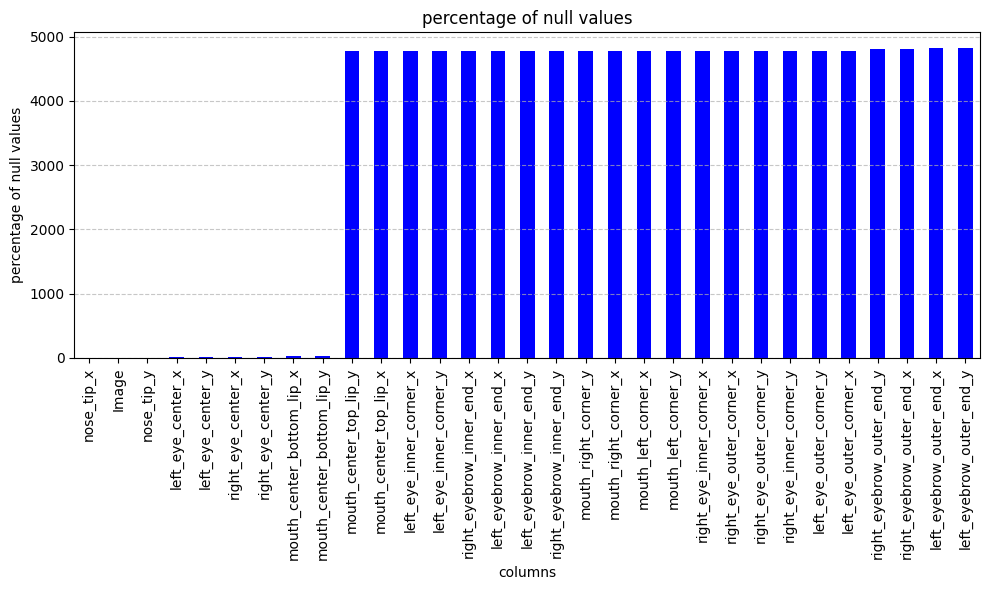

In [10]:
#checking percentage of null values in each feature
null_val = train.isnull().sum()

plt.figure(figsize=(10,6))
null_val.sort_values(ascending=True).plot(kind='bar',color='blue')
plt.title('percentage of null values')
plt.xlabel('columns')
plt.ylabel('percentage of null values')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
train.isnull().sum()

left_eye_center_x              10
left_eye_center_y              10
right_eye_center_x             13
right_eye_center_y             13
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
left_eye_outer_corner_x      4782
left_eye_outer_corner_y      4782
right_eye_inner_corner_x     4781
right_eye_inner_corner_y     4781
right_eye_outer_corner_x     4781
right_eye_outer_corner_y     4781
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
left_eyebrow_outer_end_x     4824
left_eyebrow_outer_end_y     4824
right_eyebrow_inner_end_x    4779
right_eyebrow_inner_end_y    4779
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
nose_tip_x                      0
nose_tip_y                      0
mouth_left_corner_x          4780
mouth_left_corner_y          4780
mouth_right_corner_x         4779
mouth_right_corner_y         4779
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_b

In [12]:
#carrying out the imputation of columns with null values
train_df = train.copy()
num_col = train_df.select_dtypes(include=['number']).columns
train_df[num_col] = train_df[num_col].fillna(train_df[num_col].median())

In [13]:
train_df.isnull().sum()

left_eye_center_x            0
left_eye_center_y            0
right_eye_center_x           0
right_eye_center_y           0
left_eye_inner_corner_x      0
left_eye_inner_corner_y      0
left_eye_outer_corner_x      0
left_eye_outer_corner_y      0
right_eye_inner_corner_x     0
right_eye_inner_corner_y     0
right_eye_outer_corner_x     0
right_eye_outer_corner_y     0
left_eyebrow_inner_end_x     0
left_eyebrow_inner_end_y     0
left_eyebrow_outer_end_x     0
left_eyebrow_outer_end_y     0
right_eyebrow_inner_end_x    0
right_eyebrow_inner_end_y    0
right_eyebrow_outer_end_x    0
right_eyebrow_outer_end_y    0
nose_tip_x                   0
nose_tip_y                   0
mouth_left_corner_x          0
mouth_left_corner_y          0
mouth_right_corner_x         0
mouth_right_corner_y         0
mouth_center_top_lip_x       0
mouth_center_top_lip_y       0
mouth_center_bottom_lip_x    0
mouth_center_bottom_lip_y    0
Image                        0
dtype: int64

In [14]:
train.shape

(7049, 31)

In [15]:
test_df = test.copy()

In [16]:
train.Image

0       238 236 237 238 240 240 239 241 241 243 240 23...
1       219 215 204 196 204 211 212 200 180 168 178 19...
2       144 142 159 180 188 188 184 180 167 132 84 59 ...
3       193 192 193 194 194 194 193 192 168 111 50 12 ...
4       147 148 160 196 215 214 216 217 219 220 206 18...
                              ...                        
7044    71 74 85 105 116 128 139 150 170 187 201 209 2...
7045    60 60 62 57 55 51 49 48 50 53 56 56 106 89 77 ...
7046    74 74 74 78 79 79 79 81 77 78 80 73 72 81 77 1...
7047    254 254 254 254 254 238 193 145 121 118 119 10...
7048    53 62 67 76 86 91 97 105 105 106 107 108 112 1...
Name: Image, Length: 7049, dtype: object

In [17]:
len(train['Image'].iloc[0].split()) #hence it should be converted to 96x96

9216

In [18]:
#see if the train.Image is of str 
train_df['Image'] = train_df['Image'].astype('str')

#split the string ans convert it into float32
train_df['Image'] = train_df['Image'].apply(lambda x: np.array(x.split(), dtype=np.float32))

#normalising the pixels values
train_df['Image'] = train_df['Image'].apply(lambda x: x/255.0)

In [19]:
len(train_df['Image'][0])

9216

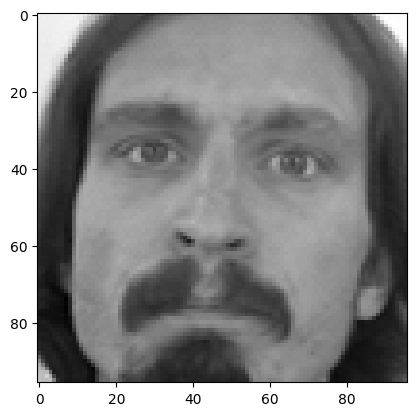

In [20]:
plt.imshow(train_df['Image'][0].reshape(96,96),cmap='gray')

In [21]:
#plotting image with facial keypoints
def plot_image(image,keypoints):
    img = image.reshape(96,96)
    plt.imshow(img, cmap='gray')
    if keypoints.isnull().sum()==0:
        keypoints = keypoints.values.astype(float)
        x_coors = keypoints[0::2]
        y_coors = keypoints[1::2]
        plt.scatter(x_coors,y_coors,s=20,c='red',marker='o')
    plt.show()

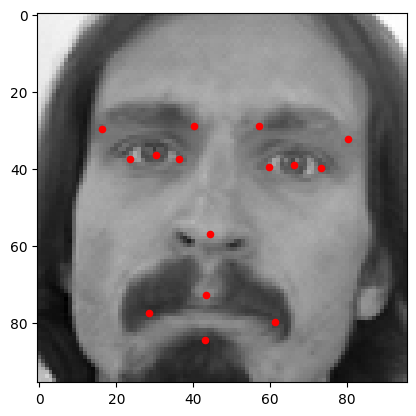

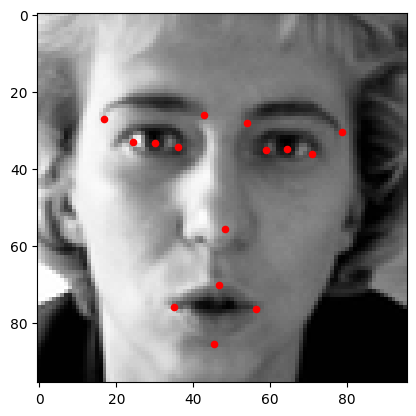

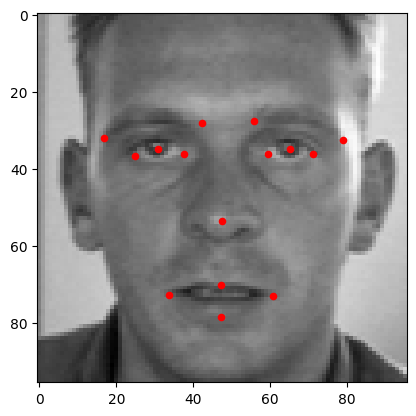

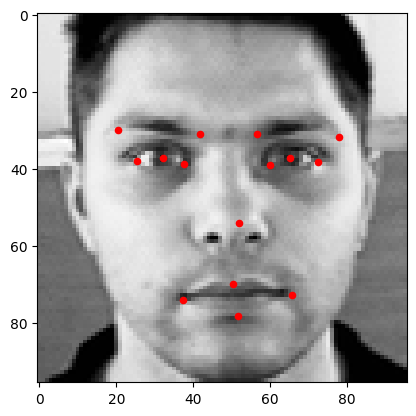

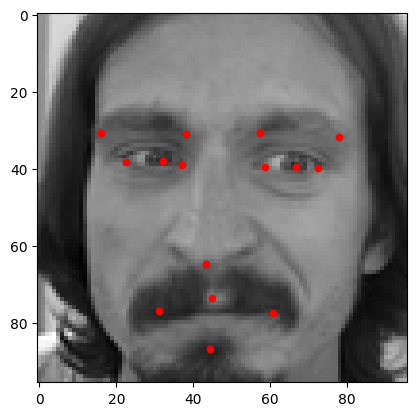

In [22]:
#visualising the first 5 images:
for i in range(5):
    image_pixel = train_df.loc[i,'Image']
    keypoints = train_df.drop('Image',axis=1).iloc[i]
    plot_image(image_pixel,keypoints)

In [23]:
train_df.Image[0]

array([0.93333334, 0.9254902 , 0.92941177, ..., 0.27450982, 0.29411766,
       0.3529412 ], dtype=float32)

In [24]:
#converting images from string to np.array and also reshaping and normalising them
#def preprocess(data):
    #images = np.array([np.fromstring(img,sep=' ') for img in train_df['Image']])
    #images = images//255.0
    #images = images.reshape(-1,96,96,1)
    #return images

In [25]:
#before splitting we need to feed tensorflow a 4d array 
img = np.stack(train_df['Image'].values)

#reshaping img
img = img.reshape(-1,96,96,1)

In [26]:
#checking the image dimensions
img.shape

(7049, 96, 96, 1)

In [27]:
X_train = img
y_train = train_df.drop(labels=['Image'],axis=1)

In [28]:
#performing the same preprocessing steps on the test data
test_df['Image'] = test_df['Image'].astype('str')

test_df['Image'] = test_df['Image'].apply(lambda x: np.array(x.split(),dtype=np.float32))

test_df['Image'] = test_df['Image'].apply(lambda x:x/255.0)

test_img = np.stack(test_df['Image'].values)
test_img = test_img.reshape(-1,96,96,1)

In [29]:
test_img.shape

(1783, 96, 96, 1)

In [30]:
#splitting the data into train test split
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [31]:
#now making a convolution sequential model
model = Sequential([
    Conv2D(32, (5,5), activation='relu',padding='same',input_shape=(96,96,1)),
    Conv2D(32, (5,5), activation='relu',padding='same',input_shape=(96,96,1)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(30,activation='linear')
    
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 96, 96, 32)          │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,359,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           7,710 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,555,838 (13.56 MB)

 Trainable params: 3,555,838 (13.56 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
def rsme(y_true,y_pred):
    return k.sqrt(k.mean(k.square(y_pred-y_true)))

In [34]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=[rsme])

In [35]:
annaeler = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr = 1e-6,
)

In [36]:
model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=50,batch_size=32,verbose=1,callbacks=[annaeler])

Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - loss: 832.9836 - rsme: 25.0164 - val_loss: 55.4230 - val_rsme: 7.4523 - learning_rate: 0.0010
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 83.8616 - rsme: 9.1357 - val_loss: 9.6026 - val_rsme: 3.0726 - learning_rate: 0.0010
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 63.7017 - rsme: 7.9425 - val_loss: 13.3474 - val_rsme: 3.6382 - learning_rate: 0.0010
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 50.1181 - rsme: 7.0567 - val_loss: 16.9503 - val_rsme: 4.0831 - learning_rate: 0.0010
Epoch 5/50
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 52.2302 - rsme: 7.1645
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 52.1547 - rsme: 7.1595 - val_loss: 19.7331 - val_rsme: 4.4356 - learning_rate: 0.0010
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 41.3295 - rsme: 6.4086 - val_loss: 8.6251 - val_rsme:

In [37]:
result = model.predict(test_img)

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


In [38]:
sub = pd.read_csv('/kaggle/input/facial-keypoints-detection/SampleSubmission.csv')
sub.head()

,RowId,Location
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [39]:
idlookup

,RowId,ImageId,FeatureName,Location
0,1,1,left_eye_center_x,NaN
1,2,1,left_eye_center_y,NaN
2,3,1,right_eye_center_x,NaN
3,4,1,right_eye_center_y,NaN
4,5,1,left_eye_inner_corner_x,NaN
...,...,...,...,...
27119,27120,1783,right_eye_center_y,NaN
27120,27121,1783,nose_tip_x,NaN
27121,27122,1783,nose_tip_y,NaN
27122,27123,1783,mouth_center_bottom_lip_x,NaN


In [40]:
lookid_list = list(idlookup['FeatureName'])
imageid = list(idlookup['ImageId']-1)
pre_list = list(result)

In [41]:
rowid = idlookup['RowId']
rowid = list(rowid)

In [42]:
feature = []

for f in lookid_list:
    feature.append(lookid_list.index(f))

In [43]:
location = []

for x,y in zip(imageid,feature):
    location.append(pre_list[x][y])

In [44]:
rowid = pd.Series(rowid,name='RowId')
loc = pd.Series(location,name='Location')
submission = pd.concat([rowid,loc],axis=1)

In [45]:
submission.to_csv('Submission.csv',index=False)